# [LAB 07] 4. 대응표본 T-Test
## #연습문제


In [82]:
from hossam import load_data
from helpers import my_plot, my_stats
from pandas import melt, DataFrame, pivot

#### 문제 1 - 피임약 복용이 혈압에 영향을 주는지?

In [83]:
df1 = load_data('blood_pressure')
df1.head()

📚 부인 15명을 대상으로 평상시 혈압을 측정한 뒤, 이들에게 이 피임약을 일정 기간 복용하게 한 후 이들의 혈압을 다시 측정한 결과를 기록한 데이터 (출처: 방송통신대학교 통계학개론)


,복용전,복용후
0,70,68
1,80,72
2,72,62
3,76,70
4,76,58


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

복용전 vs. 복용후: t-test paired samples, P_val:7.749e-03 t=3.105e+00


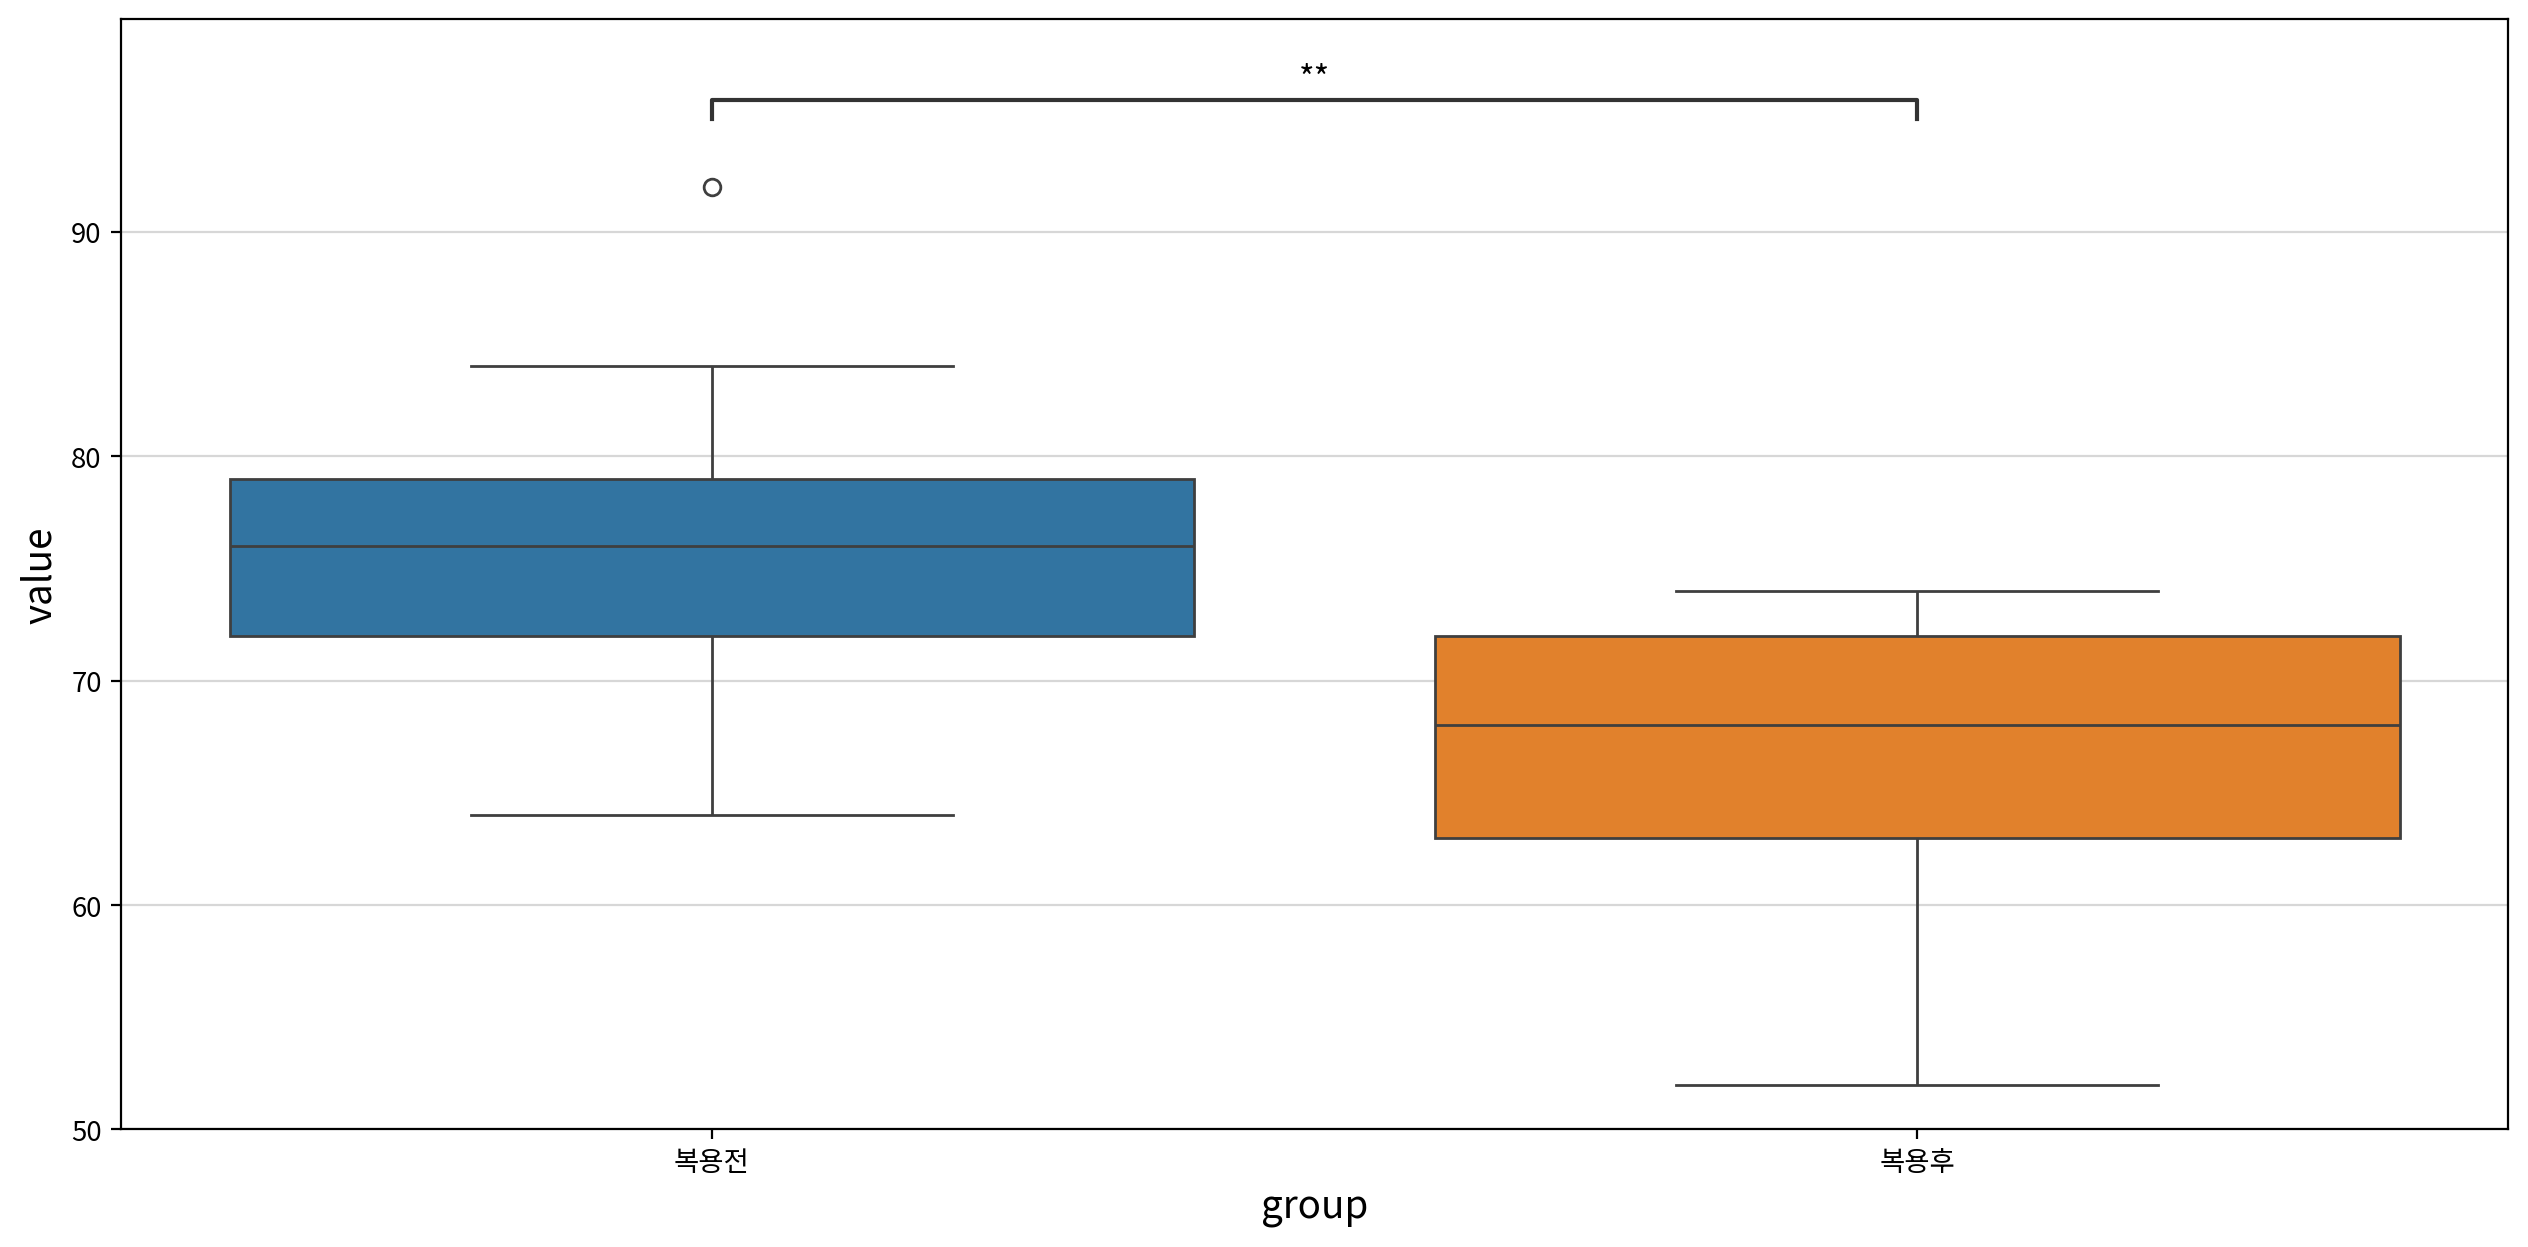

statistic  p-value  significant    result
test          alternative                                           
Paired t-test two-sided       -3.105    0.008         True     차이 있음
              less            -3.105    0.004         True  복용후 <복용전
              greater         -3.105    0.996        False     차이 없음

In [84]:
my_stats.test_paired(data=df1, before='복용전', after='복용후')

- 정규성 충족하여 paired t-test 진행
- 차이값에 대한 양측검정 수행결과 귀무가설을 기각하고 대립가설을 채택한다(p<0.05). 즉, 피임약 복용 전후 혈압에는 통계적으로 유의미한 차이가 있다.
- 피임약을 복용하기 전과 피임약 복용 후 혈압에 대해 좌측 단측검정 수행결과 통계적으로 유의미한 차이가 있다. 즉 피임약 복용 후 혈압이 낮아지는 영향을 준다.
- 피임약을 복용하기 전과 피임약 복용 후 혈압에 대해 우측 단측검정 수행결과 통계적으로 유의미한 차이를 보이지 않았다. 피임약이 혈압을 높게하거나 혈압에 영향을 주는지 알 수 없다.
- 즉 피임약 복용 후 혈압이 유의하게 감소하였다. (다만 이 데이터는 부인 15명을 대상으로 측정한 것이므로 한계가 있음)

#### 문제 2 - 감량 전과 후에 달리기 속도에 차이가 있는지?

In [85]:
df2 =load_data('runner_diet')
df2.head()

📚 고등학교 육상선수 10명에게 감량훈련(2~4kg 정도)을 시킨 후 100m 달리기를 실시한 결과를 조사한 데이터 (출처: 방송통신대학교 통계학개론)


,감량전,감량후
0,14.500,14.300
1,13.400,13.400
2,13.000,13.100
3,14.500,13.900
4,13.300,13.100


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

감량전 vs. 감량후: t-test paired samples, P_val:4.155e-02 t=2.375e+00


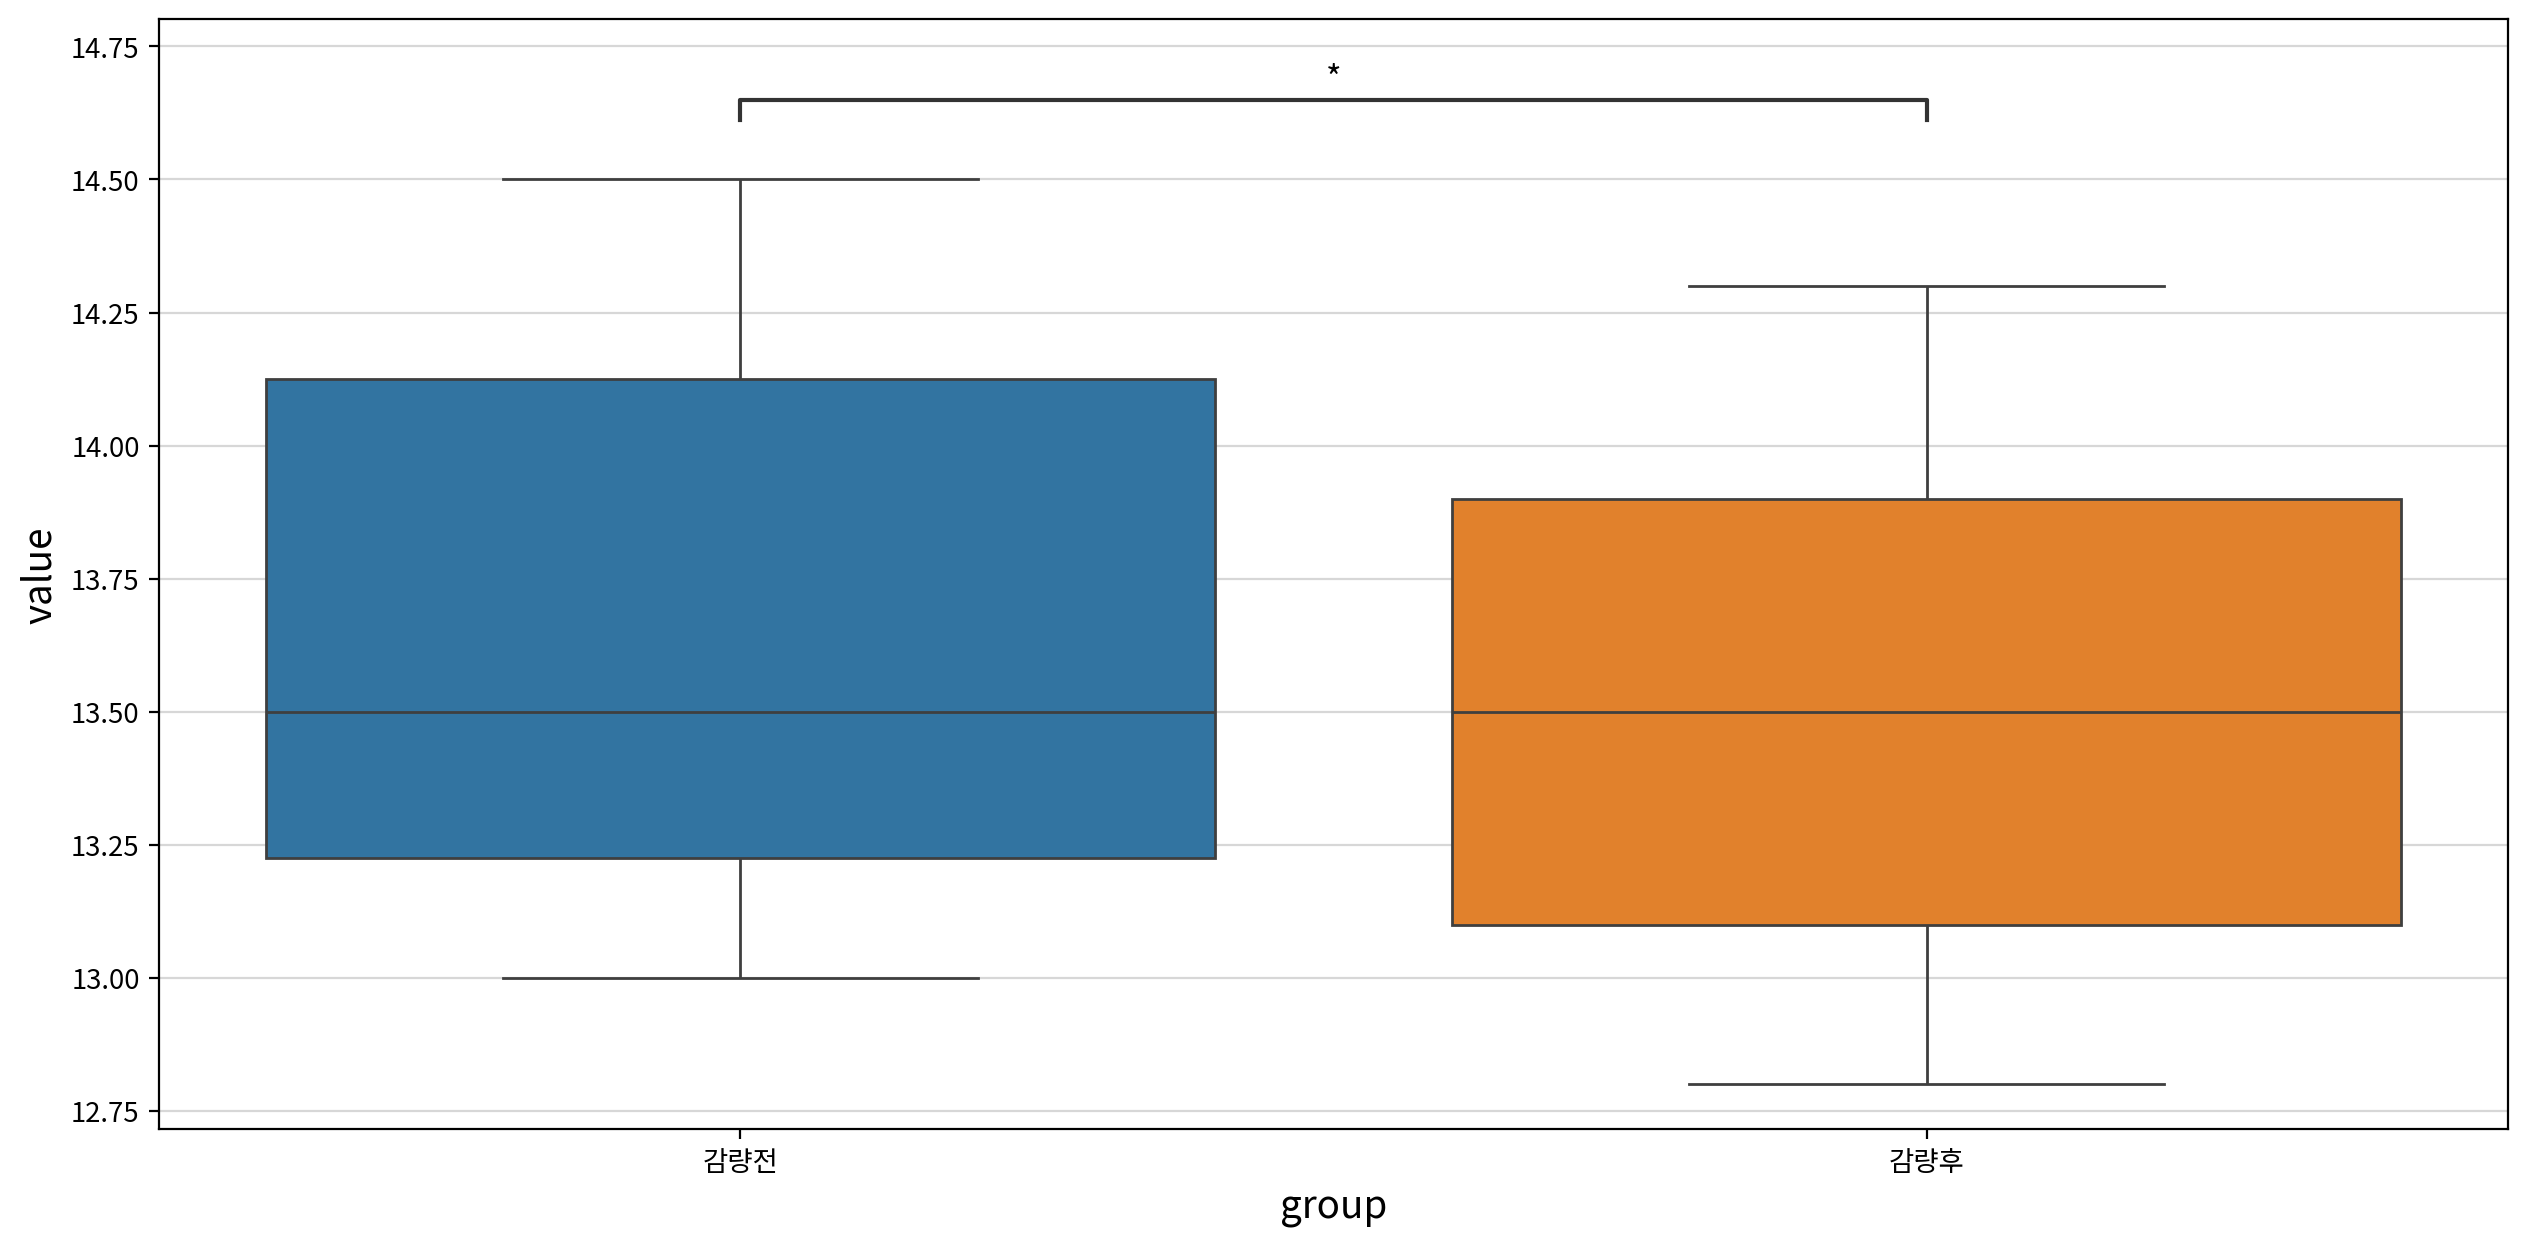

statistic  p-value  significant    result
test          alternative                                           
Paired t-test two-sided       -2.375    0.042         True     차이 있음
              less            -2.375    0.021         True  감량후 <감량전
              greater         -2.375    0.979        False     차이 없음

In [86]:
my_stats.test_paired(data=df2, before='감량전', after='감량후')

- 정규성 충족하여 paired t-test 진행
- 차이값에 대한 양측검정 수행결과 귀무가설을 기각하고 대립가설을 채택한다(p<0.05). 즉, 체중감량과 100m 달리기 기록에는 통계적으로 유의미한 차이가 있다
- 좌측 단측검정 수행결과 p-value는 0.021로 통계적으로 유의미한 차이가 있다. 즉, 체중감량 후가 체중감량 전보다 100m 달리기 기록이 단축되어 나타났다. 달리기 속도가 더 빠르게 나타났다.
- 우측 단측검정 수행결과 p-value는 0.979로 통계적으로 유의미한 차이를 보이지 않았다. 따라서 체중감량 후 100m 달리기 기록이 증가 되었다고 할 수 없다. 
- 즉, 체중감량 후 달리기 속도가 유의미하게 증가하였다.(다만 이 표본은 육상선수 10명을 대상으로 측정한 것이므로 한계가 있음)

#### 문제 3 - 체중감량과 체력변화는 영향이 있는가?

In [87]:
df3 =load_data('wrestler_diet')
df3.head()

📚 고등학교 레슬링 선수에게 체중감량을 시키면 체력에 어떤 변화가 일어나는지 조사하기 위하여, 어느 고등학교의 레슬링 선수 12명을 표본추출하여 감량시킨 후 얻은 데이터 (출처: 방송통신대학교 통계학개론)


,이름,감량전 악력,감량후 악력,감량전 윗몸일으키기,감량후 윗몸일으키기,감량전 턱걸이,감량후 턱걸이
0,B.S,43,41,35,41,25,29
1,P.J,42,41,40,44,25,29
2,G.G,52,50,36,41,22,23
3,A.L,53,52,38,42,10,15
4,I.H,44,40,36,42,15,19


In [88]:
df3_melt = melt(df3,id_vars='이름', value_vars=['감량전 악력', '감량전 윗몸일으키기', '감량전 턱걸이','감량후 악력', '감량후 윗몸일으키기', '감량후 턱걸이'],
    var_name='항목',value_name='값')
df3_melt.head()

,이름,항목,값
0,B.S,감량전 악력,43
1,P.J,감량전 악력,42
2,G.G,감량전 악력,52
3,A.L,감량전 악력,53
4,I.H,감량전 악력,44


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

감량전 악력 vs. 감량후 악력: Wilcoxon test (paired samples), P_val:3.516e-02 Stat=9.000e+00


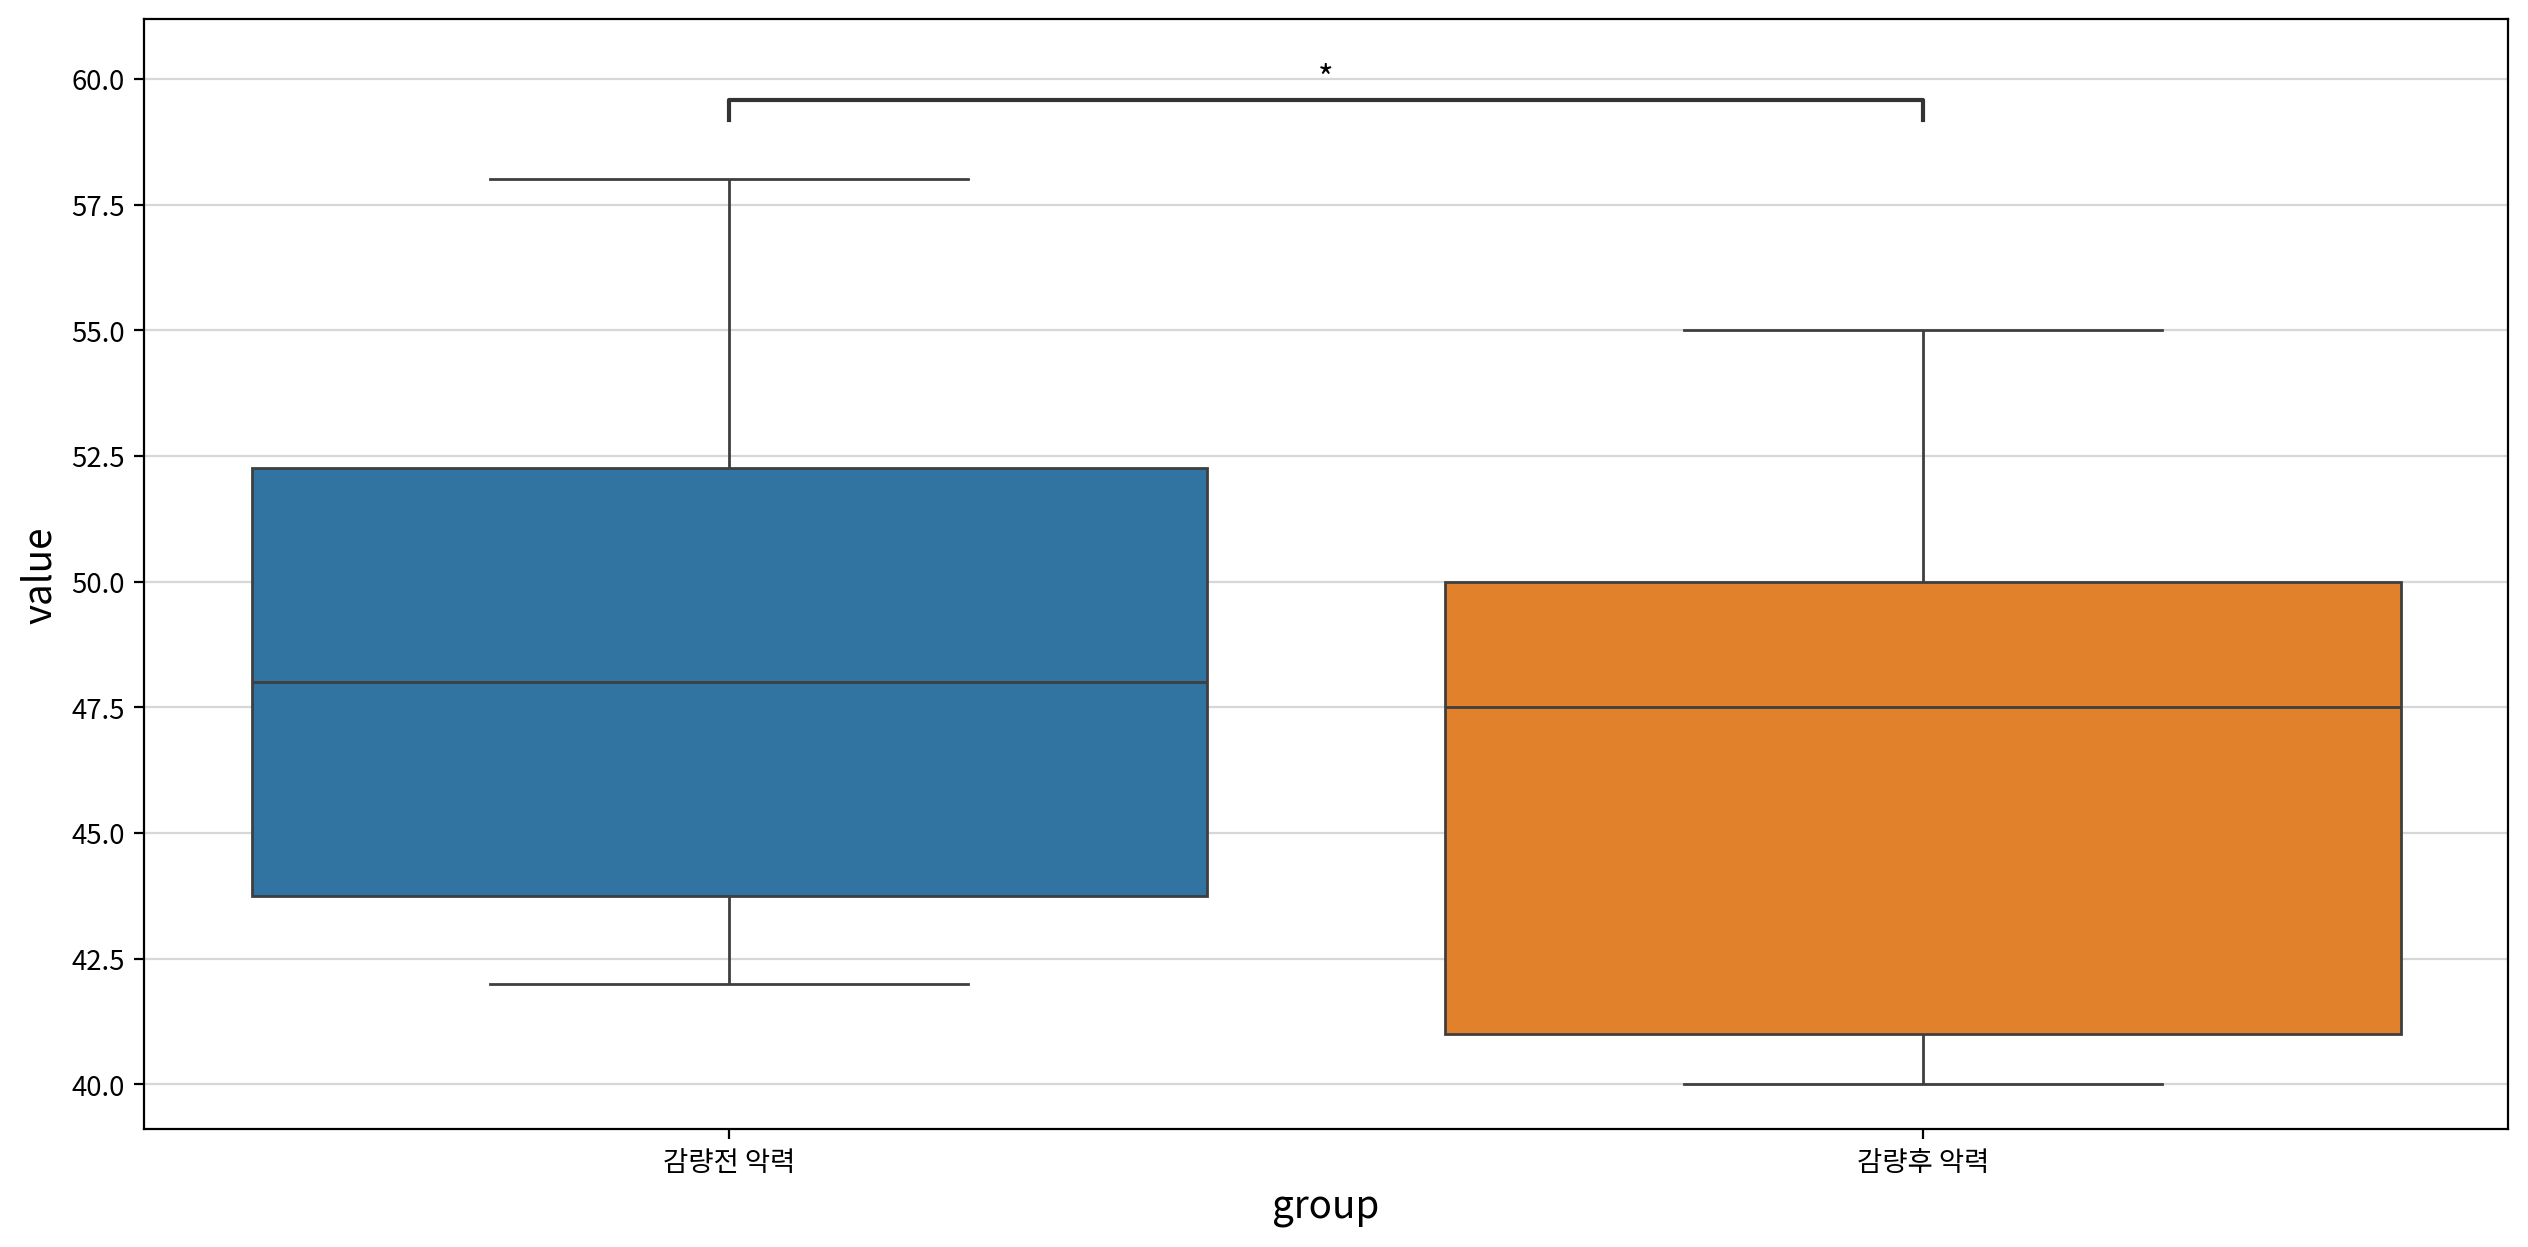

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided        9.000    0.035         True   
                          less             9.000    0.018         True   
                          greater          9.000    0.991        False   

                                               result  
test                      alternative                  
Wilcoxon signed-rank test two-sided             차이 있음  
                          less         감량후 악력 <감량전 악력  
                          greater               차이 없음

In [89]:
my_stats.test_paired(df3,before='감량전 악력',after='감량후 악력')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

감량전 윗몸일으키기 vs. 감량후 윗몸일으키기: t-test paired samples, P_val:1.798e-05 t=-7.180e+00


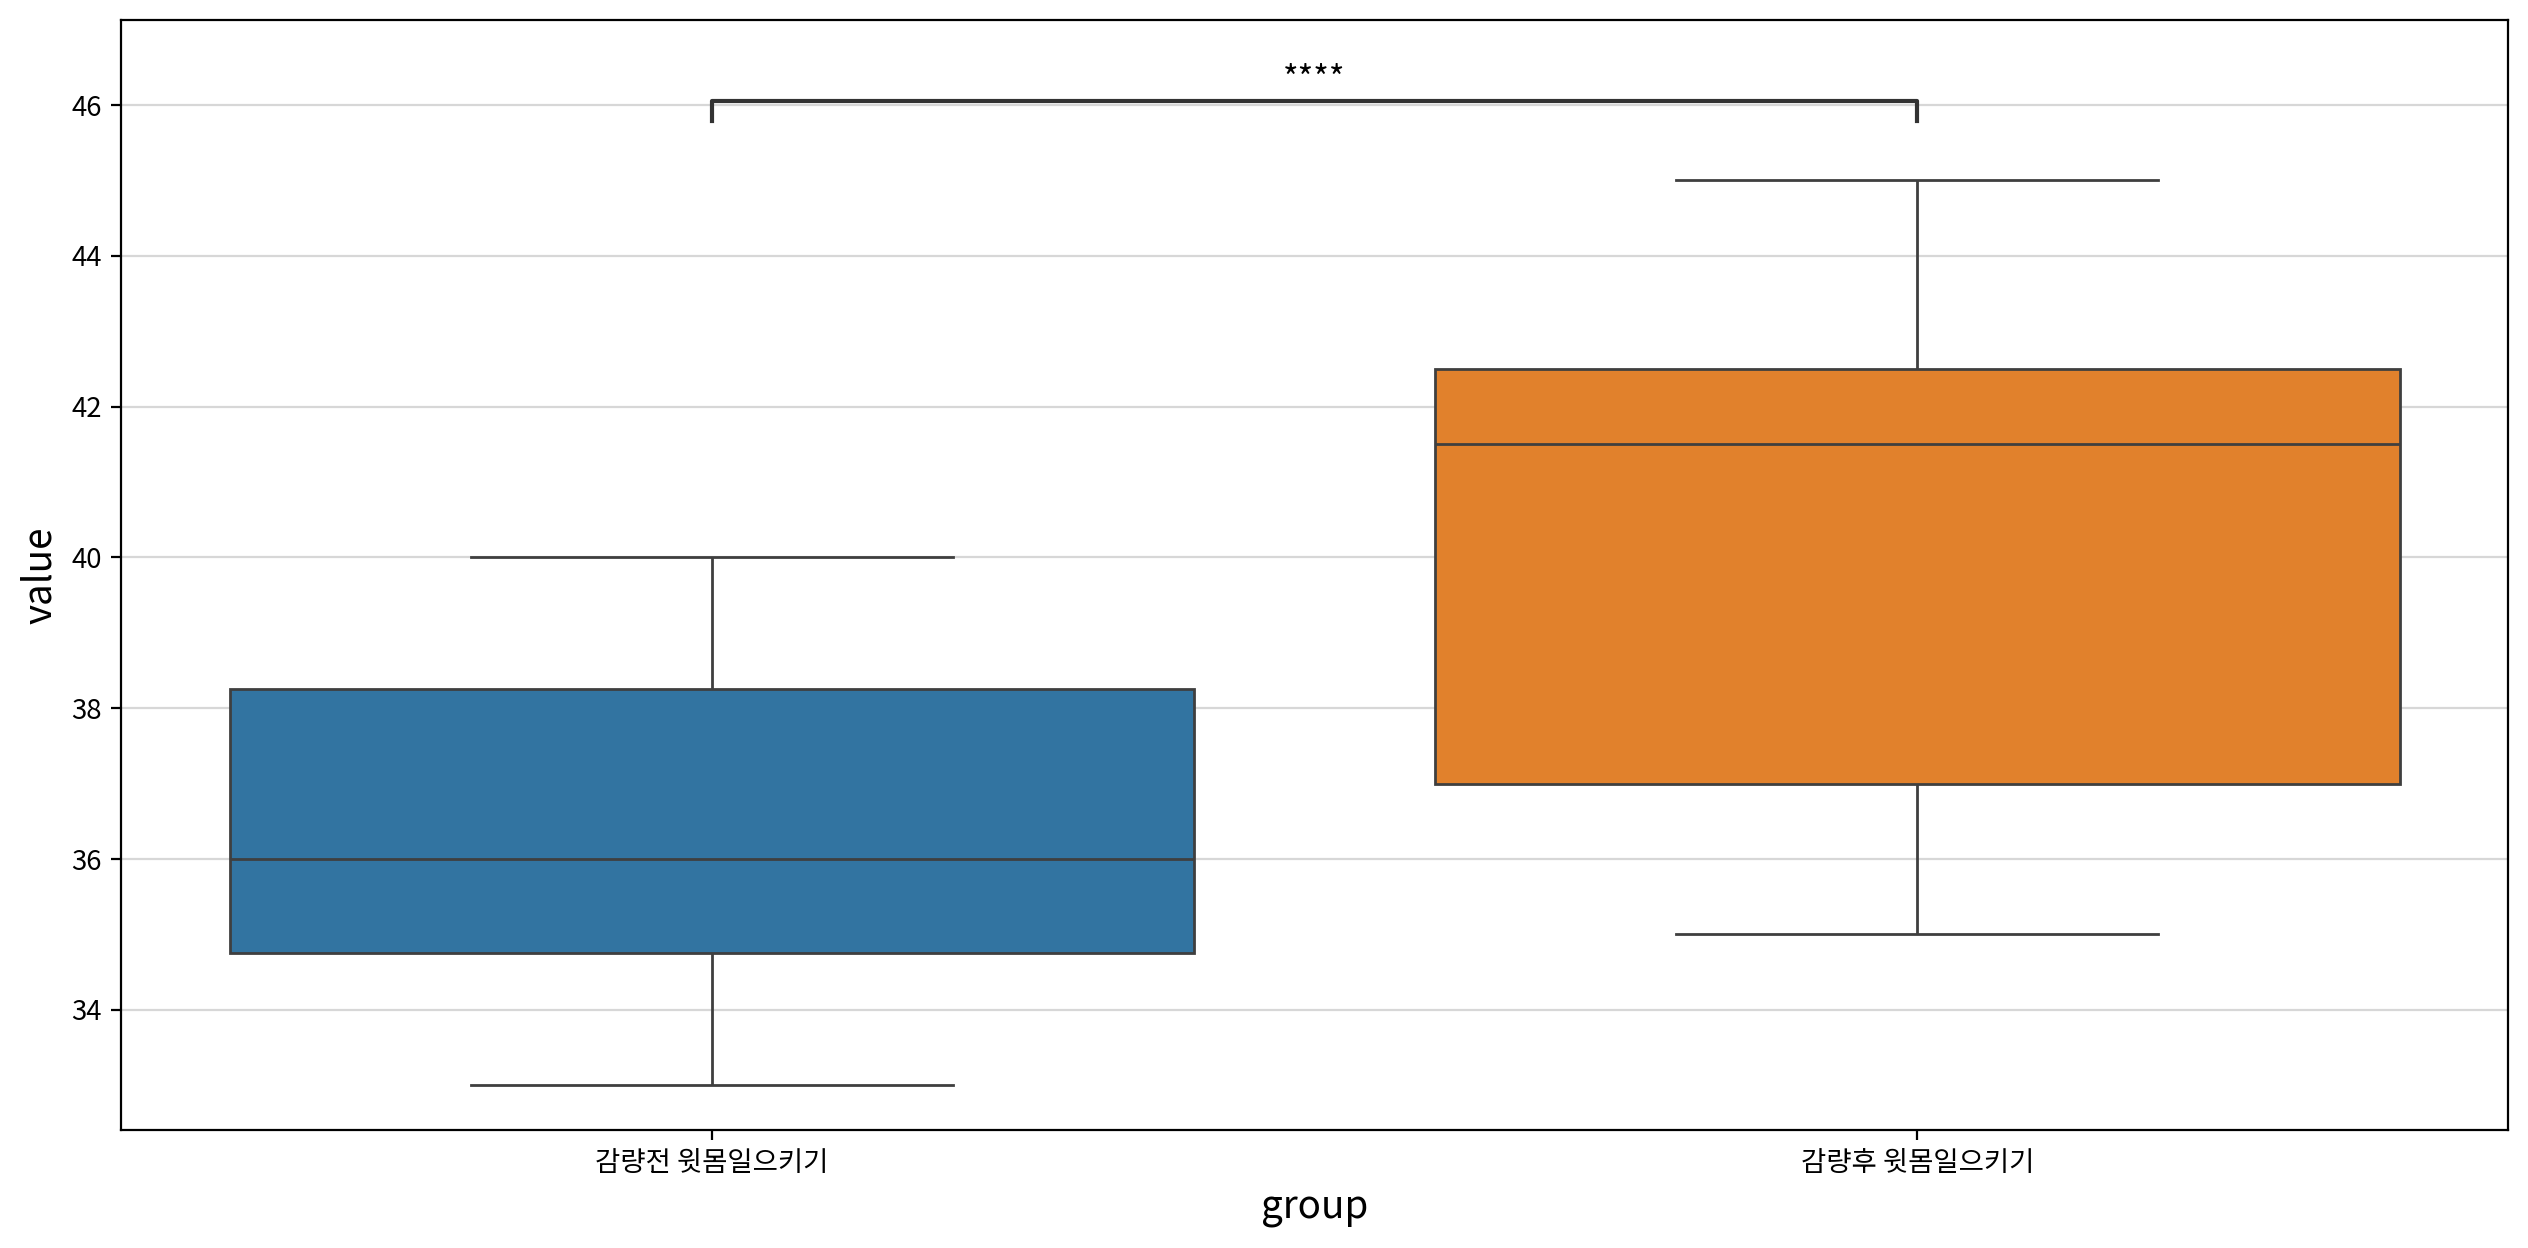

statistic  p-value  significant  \
test          alternative                                    
Paired t-test two-sided        7.180    0.000         True   
              less             7.180    1.000        False   
              greater          7.180    0.000         True   

                                          result  
test          alternative                         
Paired t-test two-sided                    차이 있음  
              less                         차이 없음  
              greater      감량후 윗몸일으키기>감량전 윗몸일으키기

In [90]:
my_stats.test_paired(df3,before='감량전 윗몸일으키기',after='감량후 윗몸일으키기')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

감량전 턱걸이 vs. 감량후 턱걸이: t-test paired samples, P_val:2.794e-05 t=-6.842e+00


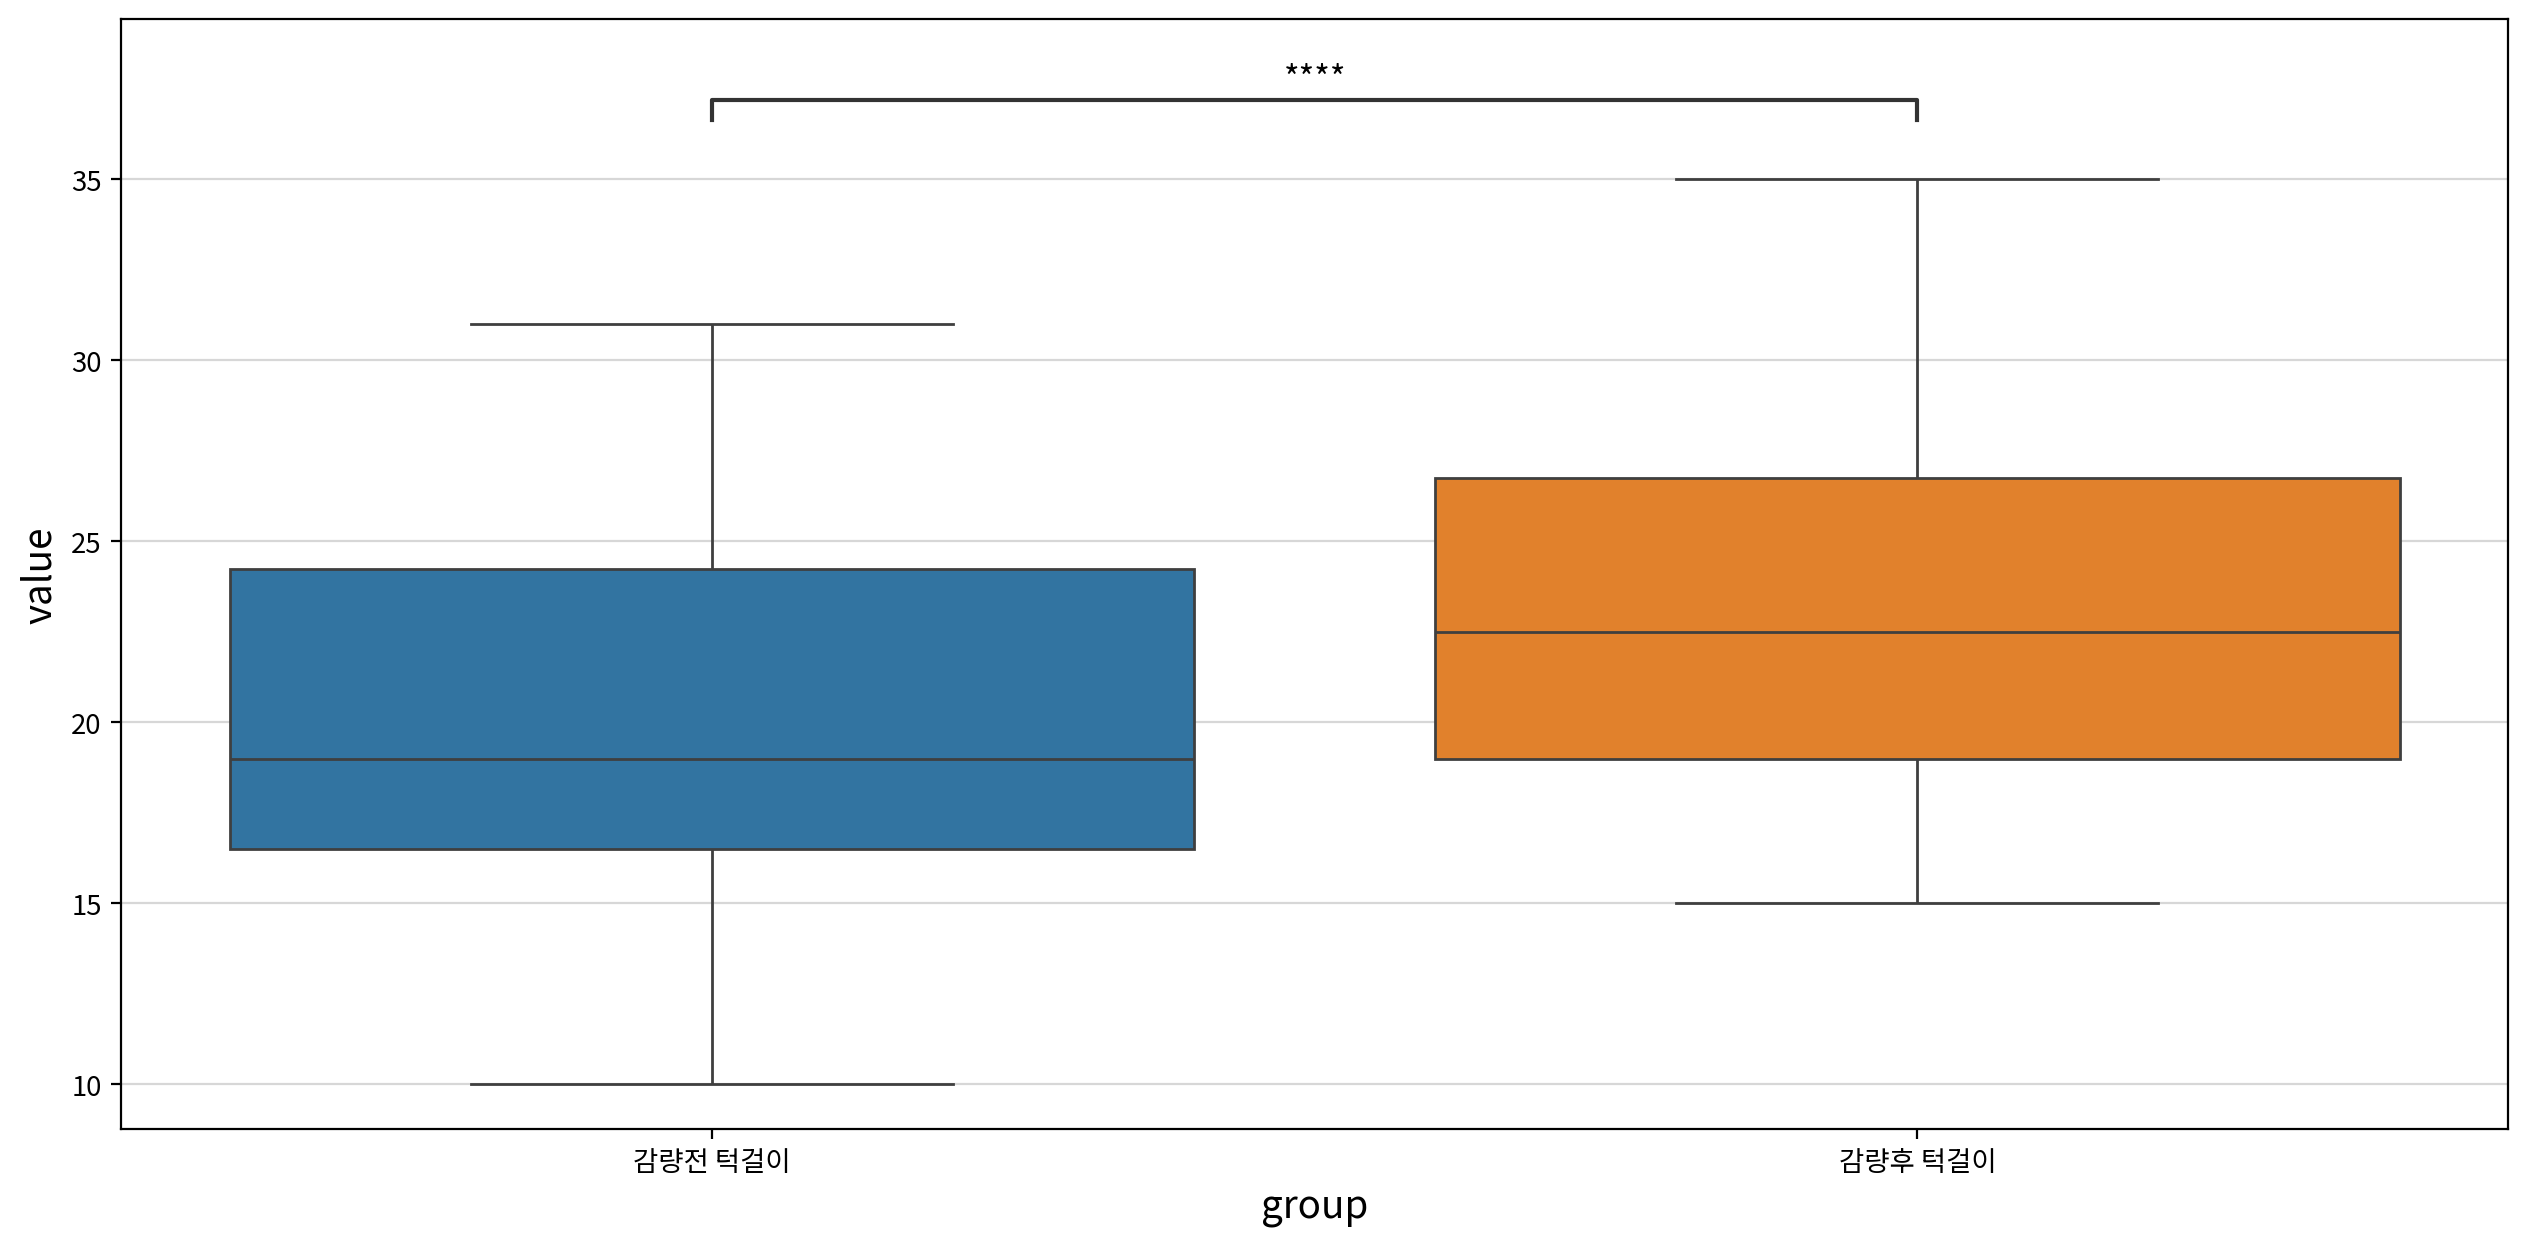

statistic  p-value  significant           result
test          alternative                                                  
Paired t-test two-sided        6.842    0.000         True            차이 있음
              less             6.842    1.000        False            차이 없음
              greater          6.842    0.000         True  감량후 턱걸이>감량전 턱걸이

In [91]:
my_stats.test_paired(df3,before='감량전 턱걸이',after='감량후 턱걸이')

1) 악력
- 정규성 분포를 충족하지 못하여 Wilcoxon signed-rank test 진행
- 양측검정 결과 p-value가 0.035로 p<0.05이므로 귀무가설을 기각한다. 따라서 체중감량과 악력에는 통계적으로 유의미한 차이가 있다.
- 좌측단측 검정결과 p-value가 0.018로 p<0.05이므로 귀무가설을 기각한다. 따라서 체중감량후 악력은 체중감량 전 악력보다 유의하게 낮은 것으로 나타났다.
- 우측단측 검정 결과 p-value는 0.991로 p>=0.05이므로 귀무가설을 채택한다. 따라서 체중 감량 후 체중감량이 악력 증가에 영향을 주지는 않았다.
- 즉 이 표본에서는 체중감량 후 약력이 유의미하게 감소한 것으로 나타났다.

2) 윗몸 일으키기
- 정규성 분포를 충족하여 Paired t-test 진행
- 양측검정 결과 p-value가 0.000으로 p<0.05이므로 귀무가설을 기각한다. 따라서 체중감량 전후 윗몸일으키기 횟수에는 통계적으로 유의미한 차이가 있다.
- 좌측단측 검정 결과 p-value가 1.000으로 p>=0.05이므로 귀무가설을 채택한다. 따라서 체중감량 후 윗몸일으키기 횟수가 감소하는데 영향을 주지는 않았다.
- 우측단측 검정 결과 p-value가 0.000으로 p<0.05이므로 귀무가설을 기각한다. 따라서 체중감량 후 윗몸일으키기 횟수는 체중감량 전보다 유의미하게 높은 것으로 나타났다.
- 즉 이 표본에서는 체중감량 후 윗몸일으키기 횟수가 유의미하게 증가한 것으로 나타났다.

3) 턱걸이
- 정규성 분포를 충족하여 Paired t-test 진행
- 양측검정 결과 p-value가 0.000으로 p<0.05이므로 귀무가설을 기각한다. 따라서 체중감량 전후 턱걸이 횟수에는 통계적으로 유의미한 차이가 있다.
- 좌측단측 검정 결과 p-value가 1.000으로 p>=0.05이므로 귀무가설을 채택한다. 따라서 체중감량 후 턱걸이 횟수 감소에 영향을 주지는 않았다.
- 우측단측 검정 결과 p-value가 0.000으로 p<0.05이므로 귀무가설을 기각한다. 따라서 체중감량 후 턱걸이 횟수는 체중감량 전보다 유의미하게 높은 것으로 나타났다.
- 즉 이 표본에서는 체중감량 후 턱걸이 횟수가 유의미하게 증가한 것으로 나타났다.

### 문제 4 - 서울시 골목상권의 2023년 상반기 하반기 매출액 차이

In [92]:
df4 = load_data('commercial')
df4.head()

📚 서울시의 2023년 상권에 따른 분기별 매출액과 매출건수에 대한 자료 (출처: 서울 열린데이터 광장)


,quarter,code,type,name,sales_amount,number_of_sales
0,1,3001491,관광특구,이태원 관광특구,72523644100,2496865
1,1,3001492,관광특구,명동 남대문 북창동 다동 무교동 관광특구,283332346393,10246122
2,1,3001493,관광특구,동대문패션타운 관광특구,81696730221,2880324
3,1,3001494,관광특구,종로·청계 관광특구,212062656625,4960006
4,1,3001495,관광특구,잠실 관광특구,231338386876,5995166


In [93]:
df5 = df4[df4['type'] == '골목상권']
df5.head()

,quarter,code,type,name,sales_amount,number_of_sales
6,1,3110001,골목상권,이북5도청사,435264344,13080
7,1,3110002,골목상권,독립문역 1번,4062721649,339647
8,1,3110003,골목상권,세검정초등학교,576819152,16978
9,1,3110004,골목상권,대신고등학교,312840339,7706
10,1,3110005,골목상권,세검정,666679997,10162


In [94]:
df5['구분'] = df5['quarter'].replace({
    1: '상반기',
    2: '상반기',
    3: '하반기',
    4: '하반기'
})

df6 = (df5.groupby(['name', '구분'])['sales_amount'].sum().reset_index())
df6.head()

,name,구분,sales_amount
0,4.19민주묘지역 2번,상반기,4205953604
1,4.19민주묘지역 2번,하반기,4664214519
2,GS강동자이아파트,상반기,5360804225
3,GS강동자이아파트,하반기,5576214898
4,G타워,상반기,4269757216


In [ ]:
df7 = df6.pivot(index='name',columns='구분',values='sales_amount').reset_index()
df7.head()

구분,name,상반기,하반기
0,4.19민주묘지역 2번,4205953604.000,4664214519.000
1,GS강동자이아파트,5360804225.000,5576214898.000
2,G타워,4269757216.000,4380482451.000
3,KB국민은행 망원동지점,7770669570.000,8199142547.000
4,KB국민은행 서강지점,1611064896.000,1699723589.000


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

상반기 vs. 하반기: Wilcoxon test (paired samples), P_val:1.709e-94 Stat=6.650e+04


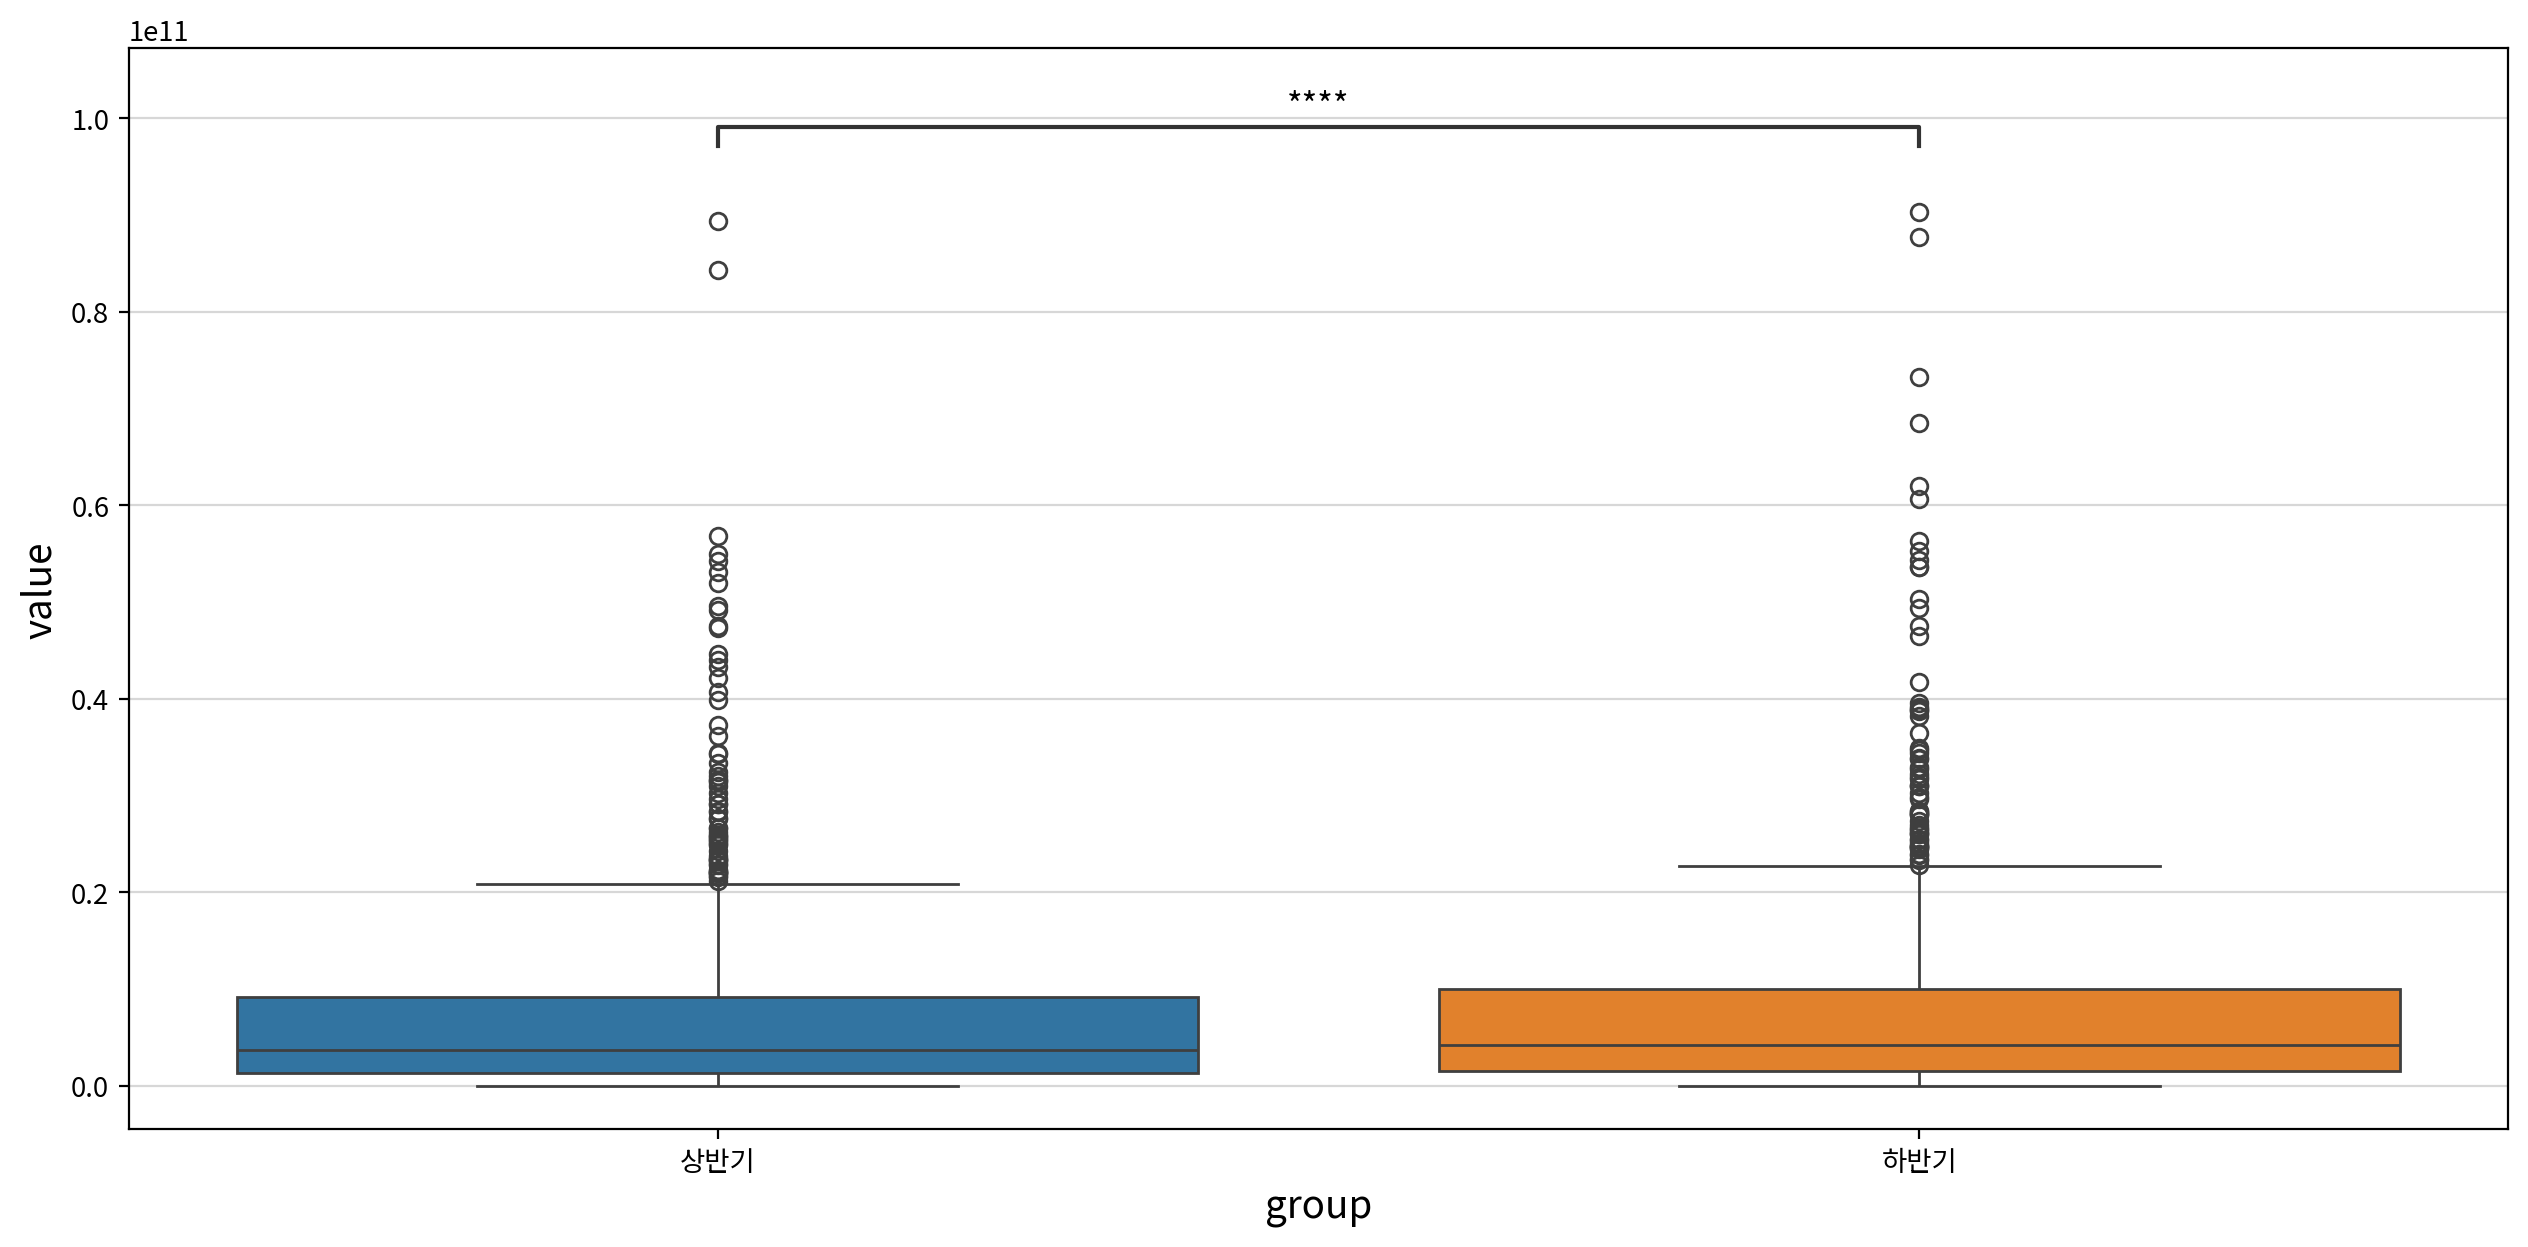

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided    66501.000    0.000         True   
                          less        455230.000    1.000        False   
                          greater     455230.000    0.000         True   

                                        result  
test                      alternative           
Wilcoxon signed-rank test two-sided      차이 있음  
                          less           차이 없음  
                          greater      하반기>상반기

In [96]:
my_stats.test_paired(df7,before='상반기',after='하반기')

- 정규성 충족하여 Wilcoxon signed-rank test 진행
- 양측검정 결과 p-value가 0.000으로 p<0.05이므로 귀무가설을 기각한다. 따라서 서울시 골목상권의 상반기와 하반기 매출액에는 통계적으로 유의미한 차이가 있다.
- 좌측단측 검정 결과 p-value가 1.000으로 p>=0.05이므로 통계적으로 유의미한 차이를 보이지 않았다. 하반기 매출액이 상반기 매출액보다 같거나 낮지 않다.
- 우측단측 검정 결과 p-value가 0.000으로 p<0.05이므로 귀무가설을 기각한다. 따라서 하반기 매출액은 상반기 매출액보다 유의미하게 높은 것으로 나타났다.
- 즉 이 표본에서는 서울시 골목상권의 하반기 매출액이 상반기 매출액보다 유의미하게 증가한 것으로 나타났다.